# CSCN8020 Assignment 2: Reinforcement Learning Programming  
## Taxi Gymnasium Environment with Q-Learning

**Student Name:** Kevinkumar Patel  
**Student ID:** 8998612  
**Repository Name:** `CSCN8020_Assignment2`

---

## Introduction

This notebook implements the **Q-Learning algorithm** on the **Taxi Gymnasium environment**. The main goal is to train an agent that can move through the Taxi grid world, pick up a passenger, and drop the passenger at the correct destination.

This is a reinforcement learning problem because the agent learns by interacting with the environment. It does not receive labelled training examples. Instead, it receives rewards and penalties from the environment and improves its policy over many episodes.

The Taxi environment has:

- **500 discrete states**
- **6 discrete actions**
- **Reward of -1** for each normal step
- **Reward of +20** for successful passenger delivery
- **Penalty of -10** for illegal pickup or drop-off

This notebook includes environment setup, object-oriented Q-Learning implementation, baseline training, training metrics, plots, hyperparameter experiments, best-combination experiment, final policy evaluation, log file creation, five required talking points, and repository file templates.


## Taxi Environment Description

The Taxi environment is a grid-world problem. The taxi must travel to the passenger location, pick up the passenger, travel to the destination, and drop off the passenger correctly.

### Action Space

| Action | Meaning |
|---|---|
| 0 | Move south / down |
| 1 | Move north / up |
| 2 | Move east / right |
| 3 | Move west / left |
| 4 | Pickup passenger |
| 5 | Drop off passenger |

### Observation Space

The environment has 500 discrete states. A state represents taxi row, taxi column, passenger location, and destination location.

The state is encoded as:

\[
((taxi\ row \times 5 + taxi\ column) \times 5 + passenger\ location) \times 4 + destination
\]

### Reward Structure

- `-1` for each step unless another reward is triggered
- `+20` for successful passenger delivery
- `-10` for illegal pickup or illegal drop-off


## Q-Learning Theory

Q-Learning is an **off-policy temporal-difference reinforcement learning algorithm**. It learns the value of taking an action in a state using a table called the **Q-table**.

The Q-table stores values for state-action pairs:

\[
Q(s,a)
\]

### Q-Learning Update Equation

\[
Q(S,A) \leftarrow Q(S,A) + \alpha [R + \gamma \max_a Q(S',a) - Q(S,A)]
\]

Where:

- \(S\) = current state
- \(A\) = selected action
- \(R\) = reward received
- \(S'\) = next state
- \(\alpha\) = learning rate
- \(\gamma\) = discount factor
- \(\max_a Q(S',a)\) = best estimated future value from the next state

### Exploration and Exploitation

This notebook uses **epsilon-greedy action selection**.

- With probability \(\epsilon\), the agent explores by selecting a random action.
- With probability \(1-\epsilon\), the agent exploits by selecting the action with the highest Q-value.


## Baseline Hyperparameters

| Hyperparameter | Symbol | Value |
|---|---:|---:|
| Learning rate | \(\alpha\) | 0.1 |
| Exploration factor | \(\epsilon\) | 0.1 |
| Discount factor | \(\gamma\) | 0.9 |


In [ ]:
# Optional installation cell
# Run this cell only if the packages are not already installed.

# !pip install gymnasium numpy pandas matplotlib jupyter

In [8]:
import os
import logging
from pathlib import Path
from dataclasses import dataclass

import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Path("logs").mkdir(exist_ok=True)
Path("images").mkdir(exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


In [9]:
# Logging setup
logger = logging.getLogger("TaxiQLearningAssignment2")
logger.setLevel(logging.INFO)

# Avoid duplicate handlers if the notebook cell is run more than once
if logger.handlers:
    logger.handlers.clear()

file_handler = logging.FileHandler("logs/assignment2_execution.log", mode="w")
formatter = logging.Formatter("%(asctime)s - %(levelname)s - %(message)s")
file_handler.setFormatter(formatter)
logger.addHandler(file_handler)

logger.info("CSCN8020 Assignment 2 Taxi Q-Learning notebook started.")
print("Logging configured. Log file will be saved at logs/assignment2_execution.log")

Logging configured. Log file will be saved at logs/assignment2_execution.log


In [10]:
@dataclass
class QLearningConfig:
    """
    Stores the hyperparameters used for Q-Learning training.
    """
    learning_rate: float = 0.1
    epsilon: float = 0.1
    discount_factor: float = 0.9
    episodes: int = 5000
    max_steps_per_episode: int = 200
    seed: int = 42

In [11]:
class TaxiEnvironmentManager:
    """
    Handles environment creation, reset, step, and environment information.
    This separates environment handling from agent behavior.
    """

    def __init__(self, env_name="Taxi-v4", seed=42):
        self.env_name = env_name
        self.seed = seed
        self.env = gym.make(env_name)
        self.env.action_space.seed(seed)

    def reset(self):
        state, info = self.env.reset(seed=self.seed)
        return state

    def step(self, action):
        next_state, reward, terminated, truncated, info = self.env.step(action)
        done = terminated or truncated
        return next_state, reward, done, info

    def close(self):
        self.env.close()

    @property
    def number_of_states(self):
        return self.env.observation_space.n

    @property
    def number_of_actions(self):
        return self.env.action_space.n

    def sample_action(self):
        return self.env.action_space.sample()

    def decode_state(self, state):
        """
        Decodes an integer state into taxi row, taxi column,
        passenger location, and destination.
        """
        return tuple(self.env.unwrapped.decode(state))

In [12]:
# Quick environment inspection
env_manager = TaxiEnvironmentManager(seed=42)

print("Environment:", env_manager.env_name)
print("Number of states:", env_manager.number_of_states)
print("Number of actions:", env_manager.number_of_actions)

sample_state = env_manager.reset()
print("Sample initial state:", sample_state)
print("Decoded sample state:", env_manager.decode_state(sample_state))

env_manager.close()

Environment: Taxi-v4
Number of states: 500
Number of actions: 6
Sample initial state: 386
Decoded sample state: (3, 4, 1, 2)


In [13]:
class QLearningAgent:
    """
    Represents the Q-Learning agent.
    The agent owns the Q-table, chooses actions, and updates Q-values.
    """

    def __init__(self, state_size, action_size, config: QLearningConfig):
        self.state_size = state_size
        self.action_size = action_size
        self.learning_rate = config.learning_rate
        self.epsilon = config.epsilon
        self.discount_factor = config.discount_factor
        self.random_generator = np.random.default_rng(config.seed)

        # Q(s, a) initialization
        self.q_table = np.zeros((state_size, action_size))

    def choose_action(self, state, environment_manager):
        """
        Epsilon-greedy action selection.
        With probability epsilon, explore randomly.
        Otherwise, exploit the best known Q-value.
        """
        random_value = self.random_generator.random()

        if random_value < self.epsilon:
            return environment_manager.sample_action()
        return int(np.argmax(self.q_table[state]))

    def update_q_value(self, state, action, reward, next_state):
        """
        Applies the Q-Learning update rule:

        Q(S,A) <- Q(S,A) + alpha * [R + gamma * max Q(S_next,a) - Q(S,A)]
        """
        old_value = self.q_table[state, action]
        best_next_value = np.max(self.q_table[next_state])

        td_target = reward + self.discount_factor * best_next_value
        td_error = td_target - old_value

        self.q_table[state, action] = old_value + self.learning_rate * td_error

    def greedy_action(self, state):
        """
        Used during evaluation. No exploration is used.
        """
        return int(np.argmax(self.q_table[state]))

In [14]:
class MetricsLogger:
    """
    Stores reward and step metrics during training.
    """

    def __init__(self):
        self.returns = []
        self.steps = []

    def log_episode(self, episode_return, episode_steps):
        self.returns.append(episode_return)
        self.steps.append(episode_steps)

    def get_dataframe(self):
        return pd.DataFrame({
            "episode": np.arange(1, len(self.returns) + 1),
            "return": self.returns,
            "steps": self.steps
        })

    def summary(self):
        return {
            "total_episodes": len(self.returns),
            "average_return": float(np.mean(self.returns)),
            "average_steps": float(np.mean(self.steps)),
            "last_500_average_return": float(np.mean(self.returns[-500:])),
            "last_500_average_steps": float(np.mean(self.steps[-500:]))
        }

In [15]:
class QLearningTrainer:
    """
    Controls the episode loop and connects the environment, agent,
    Q-value updates, and metric tracking.
    """

    def __init__(self, environment_manager, agent, config: QLearningConfig, experiment_name="baseline"):
        self.environment_manager = environment_manager
        self.agent = agent
        self.config = config
        self.experiment_name = experiment_name
        self.metrics = MetricsLogger()

    def train(self):
        logger.info(f"Training started: {self.experiment_name}")
        logger.info(
            f"Hyperparameters - alpha={self.config.learning_rate}, "
            f"epsilon={self.config.epsilon}, gamma={self.config.discount_factor}, "
            f"episodes={self.config.episodes}"
        )

        for episode in range(1, self.config.episodes + 1):
            state = self.environment_manager.reset()
            total_reward = 0
            steps = 0

            for step in range(self.config.max_steps_per_episode):
                # Choose action A from current state S
                action = self.agent.choose_action(state, self.environment_manager)

                # Take action A, observe R and S'
                next_state, reward, done, info = self.environment_manager.step(action)

                # Apply Q-Learning update rule
                self.agent.update_q_value(state, action, reward, next_state)

                # Move to next state
                state = next_state
                total_reward += reward
                steps += 1

                if done:
                    break

            self.metrics.log_episode(total_reward, steps)

            if episode % 500 == 0:
                logger.info(
                    f"{self.experiment_name} - Episode {episode}: "
                    f"Return={total_reward}, Steps={steps}"
                )

        summary = self.metrics.summary()
        logger.info(f"Training completed: {self.experiment_name}")
        logger.info(f"Final training metrics: {summary}")

        return self.metrics

    def evaluate_policy(self, evaluation_episodes=100):
        """
        Evaluates the learned greedy policy without exploration.
        """
        evaluation_returns = []
        evaluation_steps = []

        for episode in range(evaluation_episodes):
            state = self.environment_manager.reset()
            total_reward = 0
            steps = 0

            for step in range(self.config.max_steps_per_episode):
                action = self.agent.greedy_action(state)
                next_state, reward, done, info = self.environment_manager.step(action)

                state = next_state
                total_reward += reward
                steps += 1

                if done:
                    break

            evaluation_returns.append(total_reward)
            evaluation_steps.append(steps)

        evaluation_summary = {
            "evaluation_episodes": evaluation_episodes,
            "evaluation_average_return": float(np.mean(evaluation_returns)),
            "evaluation_average_steps": float(np.mean(evaluation_steps))
        }

        logger.info(f"Policy evaluation for {self.experiment_name}: {evaluation_summary}")
        return evaluation_summary

In [16]:
class PlotManager:
    """
    Handles all plots and saves generated images.
    """

    @staticmethod
    def rolling_average(values, window=100):
        return pd.Series(values).rolling(window=window).mean()

    @staticmethod
    def plot_training_curves(metrics_df, title, file_name_prefix):
        # Return per episode
        plt.figure(figsize=(10, 5))
        plt.plot(metrics_df["episode"], metrics_df["return"])
        plt.xlabel("Episode")
        plt.ylabel("Total Return")
        plt.title(f"{title} - Return per Episode")
        plt.grid(True)
        plt.savefig(f"images/{file_name_prefix}_returns.png", bbox_inches="tight")
        plt.show()

        # Steps per episode
        plt.figure(figsize=(10, 5))
        plt.plot(metrics_df["episode"], metrics_df["steps"])
        plt.xlabel("Episode")
        plt.ylabel("Steps per Episode")
        plt.title(f"{title} - Steps per Episode")
        plt.grid(True)
        plt.savefig(f"images/{file_name_prefix}_steps.png", bbox_inches="tight")
        plt.show()

        # Rolling average return
        plt.figure(figsize=(10, 5))
        plt.plot(metrics_df["episode"], PlotManager.rolling_average(metrics_df["return"], window=100))
        plt.xlabel("Episode")
        plt.ylabel("Average Return")
        plt.title(f"{title} - Rolling Average Return Over Time")
        plt.grid(True)
        plt.savefig(f"images/{file_name_prefix}_average_return.png", bbox_inches="tight")
        plt.show()

    @staticmethod
    def plot_experiment_comparison(summary_df):
        plt.figure(figsize=(12, 6))
        plt.bar(summary_df["experiment"], summary_df["last_500_average_return"])
        plt.xlabel("Experiment")
        plt.ylabel("Last 500 Episodes Average Return")
        plt.title("Hyperparameter Experiment Comparison")
        plt.xticks(rotation=45, ha="right")
        plt.grid(True)
        plt.savefig("images/experiment_comparison.png", bbox_inches="tight")
        plt.show()

    @staticmethod
    def plot_steps_comparison(summary_df):
        plt.figure(figsize=(12, 6))
        plt.bar(summary_df["experiment"], summary_df["last_500_average_steps"])
        plt.xlabel("Experiment")
        plt.ylabel("Last 500 Episodes Average Steps")
        plt.title("Steps Comparison Across Experiments")
        plt.xticks(rotation=45, ha="right")
        plt.grid(True)
        plt.savefig("images/steps_comparison.png", bbox_inches="tight")
        plt.show()

In [17]:
class ExperimentRunner:
    """
    Runs baseline, hyperparameter, and best-combination experiments.
    """

    def __init__(self):
        self.results = []
        self.metrics_dataframes = {}
        self.agents = {}

    def run_experiment(self, experiment_name, config):
        environment_manager = TaxiEnvironmentManager(seed=config.seed)

        agent = QLearningAgent(
            state_size=environment_manager.number_of_states,
            action_size=environment_manager.number_of_actions,
            config=config
        )

        trainer = QLearningTrainer(
            environment_manager=environment_manager,
            agent=agent,
            config=config,
            experiment_name=experiment_name
        )

        metrics = trainer.train()
        evaluation = trainer.evaluate_policy(evaluation_episodes=100)

        summary = metrics.summary()
        summary.update(evaluation)

        summary["experiment"] = experiment_name
        summary["alpha"] = config.learning_rate
        summary["epsilon"] = config.epsilon
        summary["gamma"] = config.discount_factor

        self.results.append(summary)
        self.metrics_dataframes[experiment_name] = metrics.get_dataframe()
        self.agents[experiment_name] = agent

        environment_manager.close()

        return summary, metrics.get_dataframe(), agent

    def get_summary_dataframe(self):
        df = pd.DataFrame(self.results)
        ordered_columns = [
            "experiment", "alpha", "epsilon", "gamma", "total_episodes",
            "average_return", "average_steps",
            "last_500_average_return", "last_500_average_steps",
            "evaluation_episodes", "evaluation_average_return", "evaluation_average_steps"
        ]
        return df[ordered_columns]

## Task 1: Baseline Q-Learning Implementation

The baseline uses:

- Learning rate \(\alpha = 0.1\)
- Exploration factor \(\epsilon = 0.1\)
- Discount factor \(\gamma = 0.9\)

The training loop follows the Q-Learning process:

1. Initialize Q-table
2. Start an episode
3. Observe current state \(S\)
4. Choose action \(A\) using epsilon-greedy strategy
5. Take action \(A\)
6. Observe reward \(R\) and next state \(S'\)
7. Update Q-value
8. Repeat until the episode ends


In [18]:
runner = ExperimentRunner()

baseline_config = QLearningConfig(
    learning_rate=0.1,
    epsilon=0.1,
    discount_factor=0.9,
    episodes=5000,
    max_steps_per_episode=200,
    seed=42
)

baseline_summary, baseline_df, baseline_agent = runner.run_experiment(
    experiment_name="baseline_alpha_0.1_epsilon_0.1",
    config=baseline_config
)

baseline_summary

{'total_episodes': 5000,
 'average_return': -0.643,
 'average_steps': 16.6414,
 'last_500_average_return': 3.002,
 'last_500_average_steps': 14.614,
 'evaluation_episodes': 100,
 'evaluation_average_return': 8.0,
 'evaluation_average_steps': 13.0,
 'experiment': 'baseline_alpha_0.1_epsilon_0.1',
 'alpha': 0.1,
 'epsilon': 0.1,
 'gamma': 0.9}

## Task 2: Baseline Training Metrics and Plots

The required metrics are:

- Total episodes
- Total steps taken per episode
- Average return per episode

The following plots are included:

- Total return per episode
- Steps per episode
- Average return over time using a rolling average


In [19]:
baseline_df.head()

,episode,return,steps
0,1,-506,200
1,2,-506,200
2,3,-443,200
3,4,-281,200
4,5,-497,200


In [20]:
baseline_df.describe()

,episode,return,steps
count,5000.000000,5000.000000,5000.000000
mean,2500.500000,-0.643000,16.641400
std,1443.520003,30.304172,17.239033
min,1.000000,-506.000000,13.000000
25%,1250.750000,-2.000000,13.000000
50%,2500.500000,6.000000,14.000000
75%,3750.250000,8.000000,16.000000
max,5000.000000,8.000000,200.000000


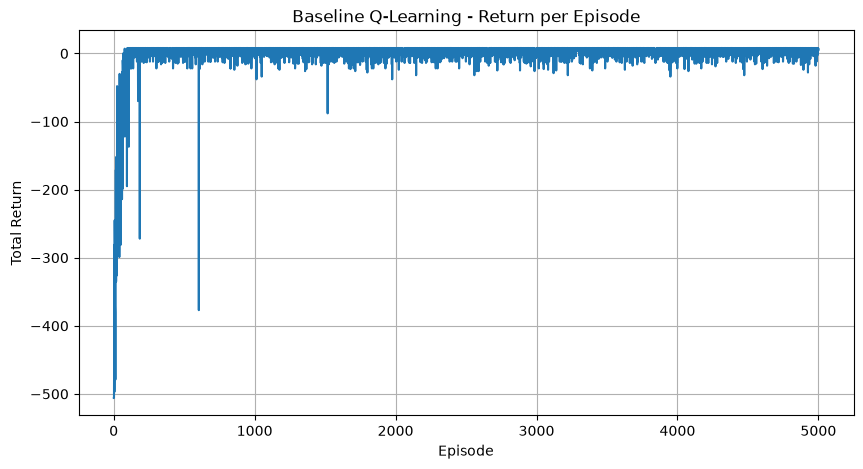

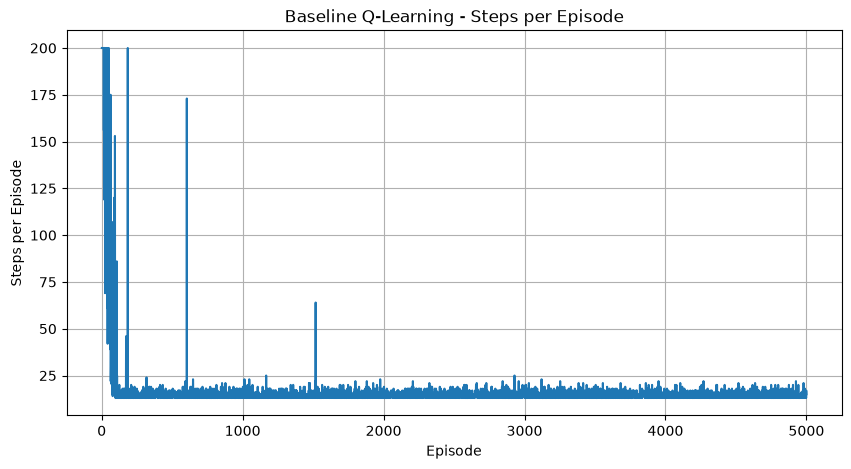

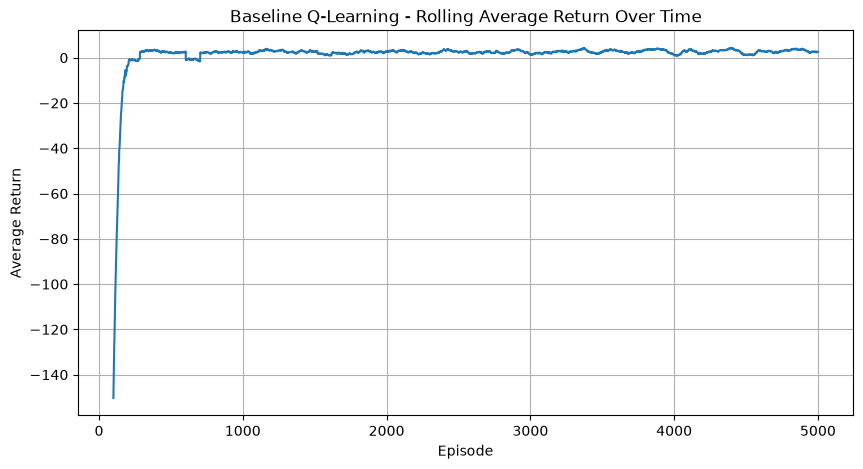

In [21]:
PlotManager.plot_training_curves(
    baseline_df,
    title="Baseline Q-Learning",
    file_name_prefix="baseline_training"
)

### Baseline Interpretation

At the beginning of training, the agent usually receives low returns because the Q-table starts with zero values and the agent does not yet know which actions are useful. The taxi may take many steps, move inefficiently, and sometimes perform illegal pickup or drop-off actions.

As training continues, the total return should improve and the number of steps should decrease. This happens because the Q-table is updated after each action using reward feedback and estimated future value. The rolling average return is useful because it shows the general learning trend more clearly than individual episode rewards.


## Task 3: Hyperparameter Experiments

The assignment requires changing the following parameters separately.

### Learning Rate Experiments

Required learning rate values:

- \(\alpha = 0.01\)
- \(\alpha = 0.001\)
- \(\alpha = 0.2\)

For these experiments, epsilon stays at the baseline value of 0.1 and gamma stays at 0.9.

### Exploration Factor Experiments

Required exploration values:

- \(\epsilon = 0.2\)
- \(\epsilon = 0.3\)

For these experiments, learning rate stays at the baseline value of 0.1 and gamma stays at 0.9.


In [22]:
# Learning rate experiments
learning_rates = [0.01, 0.001, 0.2]

for alpha in learning_rates:
    config = QLearningConfig(
        learning_rate=alpha,
        epsilon=0.1,
        discount_factor=0.9,
        episodes=5000,
        max_steps_per_episode=200,
        seed=42
    )

    experiment_name = f"alpha_{alpha}_epsilon_0.1"
    print(f"Running experiment: {experiment_name}")

    runner.run_experiment(
        experiment_name=experiment_name,
        config=config
    )

Running experiment: alpha_0.01_epsilon_0.1
Running experiment: alpha_0.001_epsilon_0.1
Running experiment: alpha_0.2_epsilon_0.1


In [23]:
# Exploration factor experiments
epsilons = [0.2, 0.3]

for epsilon in epsilons:
    config = QLearningConfig(
        learning_rate=0.1,
        epsilon=epsilon,
        discount_factor=0.9,
        episodes=5000,
        max_steps_per_episode=200,
        seed=42
    )

    experiment_name = f"alpha_0.1_epsilon_{epsilon}"
    print(f"Running experiment: {experiment_name}")

    runner.run_experiment(
        experiment_name=experiment_name,
        config=config
    )

Running experiment: alpha_0.1_epsilon_0.2
Running experiment: alpha_0.1_epsilon_0.3


In [24]:
summary_df = runner.get_summary_dataframe()
summary_df

,experiment,alpha,epsilon,gamma,total_episodes,average_return,average_steps,last_500_average_return,last_500_average_steps,evaluation_episodes,evaluation_average_return,evaluation_average_steps
0,baseline_alpha_0.1_epsilon_0.1,0.100,0.1,0.9,5000,-0.6430,16.6414,3.002,14.614,100,8.0,13.0
1,alpha_0.01_epsilon_0.1,0.010,0.1,0.9,5000,-22.9278,32.2938,2.356,14.630,100,8.0,13.0
2,alpha_0.001_epsilon_0.1,0.001,0.1,0.9,5000,-195.9516,152.0322,-96.794,88.778,100,-200.0,200.0
3,alpha_0.2_epsilon_0.1,0.200,0.1,0.9,5000,0.5838,15.8190,2.542,14.660,100,8.0,13.0
4,alpha_0.1_epsilon_0.2,0.100,0.2,0.9,5000,-8.4484,18.9070,-4.816,16.780,100,8.0,13.0
5,alpha_0.1_epsilon_0.3,0.100,0.3,0.9,5000,-18.3088,21.5446,-13.734,19.146,100,8.0,13.0


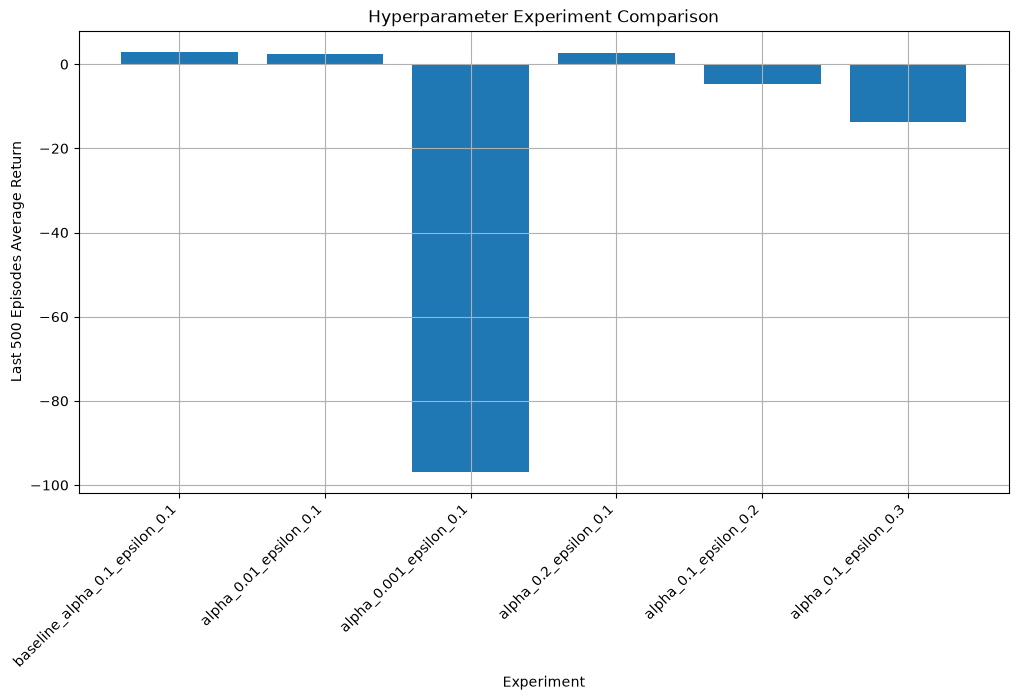

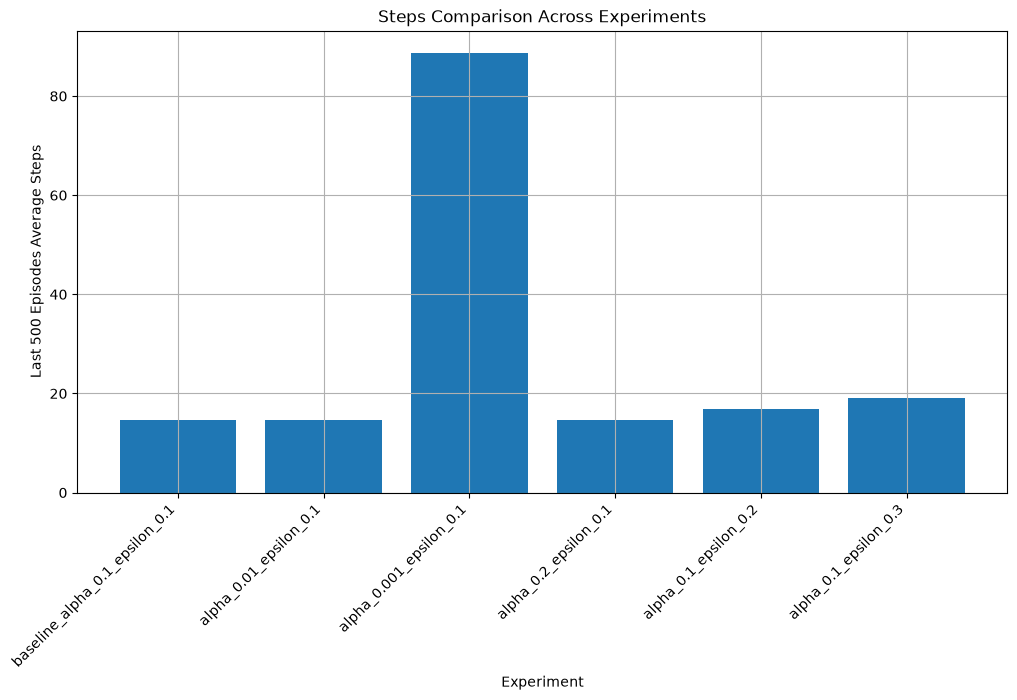

In [25]:
PlotManager.plot_experiment_comparison(summary_df)
PlotManager.plot_steps_comparison(summary_df)

### Hyperparameter Experiment Interpretation

The learning rate controls how much the Q-table changes after each update.

A very small learning rate, such as 0.001, usually learns slowly because each new reward changes the Q-values only slightly. A moderate learning rate, such as 0.1, usually provides stable learning. A larger learning rate, such as 0.2, can learn faster but may also create more unstable updates if the value changes are too aggressive.

The exploration factor controls how often the agent selects a random action.

A higher epsilon value gives the agent more exploration. This can help the agent discover better actions in more states, especially early in training. However, too much exploration can lower short-term performance because the agent continues choosing random actions even after it has learned useful Q-values.

The best experiment should have a high average return and a lower average number of steps during the last part of training.


## Task 4: Best Combination Experiment

For the best-combination experiment, this notebook selects:

- The best learning rate from the learning-rate experiments
- The best exploration factor from the epsilon experiments

The selection is based on the **highest last 500 episodes average return**.

Then the notebook re-runs training using the selected combination.


In [26]:
# Select best alpha from experiments where epsilon stayed at 0.1
alpha_experiment_names = [f"alpha_{alpha}_epsilon_0.1" for alpha in learning_rates]
alpha_results = summary_df[summary_df["experiment"].isin(alpha_experiment_names)]

best_alpha = alpha_results.sort_values(
    by="last_500_average_return",
    ascending=False
).iloc[0]["alpha"]

# Select best epsilon from experiments where alpha stayed at 0.1
epsilon_experiment_names = [f"alpha_0.1_epsilon_{epsilon}" for epsilon in epsilons]
epsilon_results = summary_df[summary_df["experiment"].isin(epsilon_experiment_names)]

best_epsilon = epsilon_results.sort_values(
    by="last_500_average_return",
    ascending=False
).iloc[0]["epsilon"]

print("Selected best alpha:", best_alpha)
print("Selected best epsilon:", best_epsilon)

Selected best alpha: 0.2
Selected best epsilon: 0.2


In [27]:
best_combo_config = QLearningConfig(
    learning_rate=float(best_alpha),
    epsilon=float(best_epsilon),
    discount_factor=0.9,
    episodes=5000,
    max_steps_per_episode=200,
    seed=42
)

best_summary, best_df, best_agent = runner.run_experiment(
    experiment_name=f"best_combo_alpha_{best_alpha}_epsilon_{best_epsilon}",
    config=best_combo_config
)

best_summary

{'total_episodes': 5000,
 'average_return': -6.7474,
 'average_steps': 17.9278,
 'last_500_average_return': -4.758,
 'last_500_average_steps': 16.776,
 'evaluation_episodes': 100,
 'evaluation_average_return': 8.0,
 'evaluation_average_steps': 13.0,
 'experiment': 'best_combo_alpha_0.2_epsilon_0.2',
 'alpha': 0.2,
 'epsilon': 0.2,
 'gamma': 0.9}

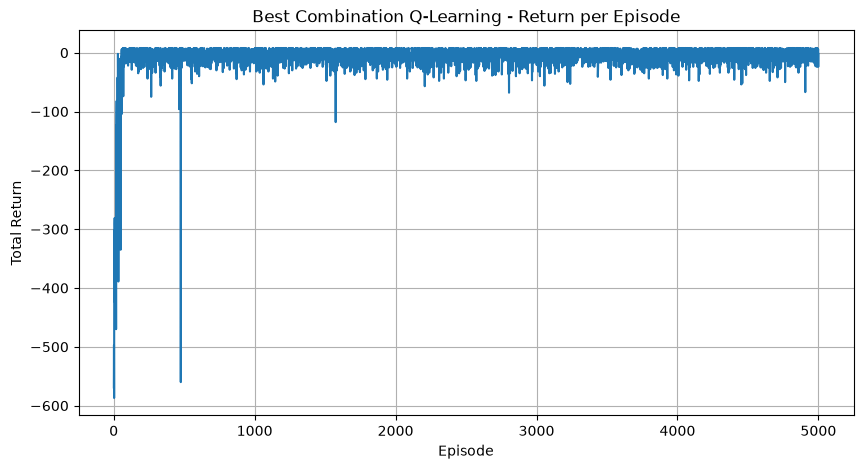

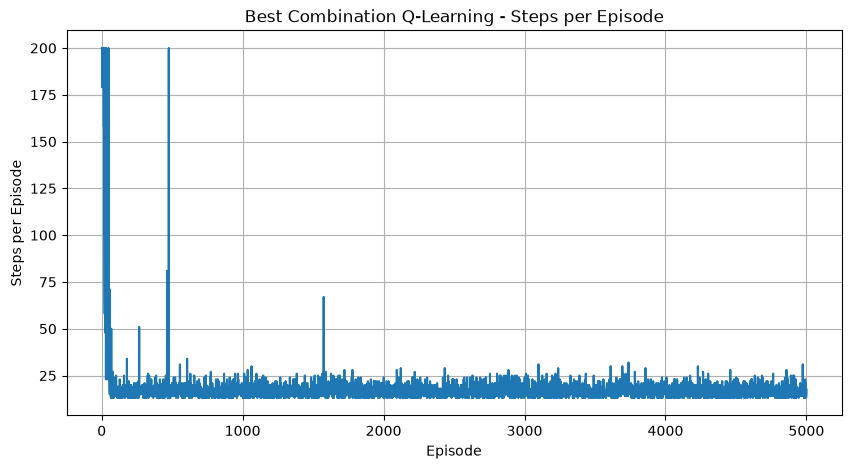

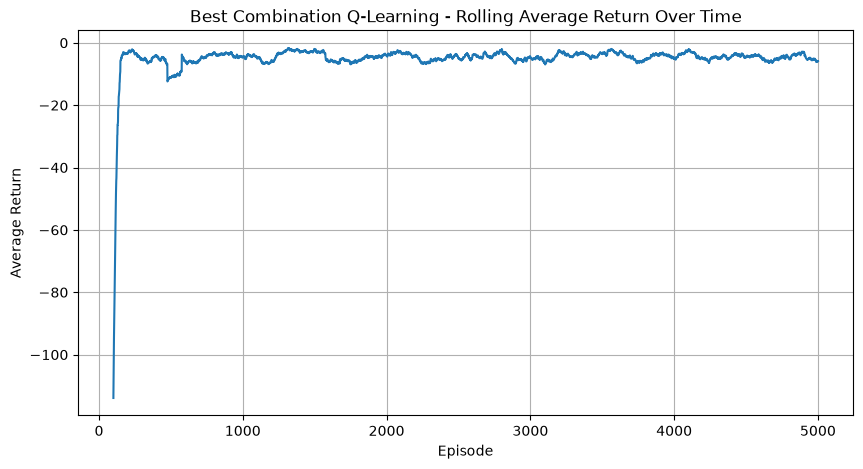

In [28]:
PlotManager.plot_training_curves(
    best_df,
    title="Best Combination Q-Learning",
    file_name_prefix="best_combo_training"
)

In [29]:
final_summary_df = runner.get_summary_dataframe()
final_summary_df

,experiment,alpha,epsilon,gamma,total_episodes,average_return,average_steps,last_500_average_return,last_500_average_steps,evaluation_episodes,evaluation_average_return,evaluation_average_steps
0,baseline_alpha_0.1_epsilon_0.1,0.100,0.1,0.9,5000,-0.6430,16.6414,3.002,14.614,100,8.0,13.0
1,alpha_0.01_epsilon_0.1,0.010,0.1,0.9,5000,-22.9278,32.2938,2.356,14.630,100,8.0,13.0
2,alpha_0.001_epsilon_0.1,0.001,0.1,0.9,5000,-195.9516,152.0322,-96.794,88.778,100,-200.0,200.0
3,alpha_0.2_epsilon_0.1,0.200,0.1,0.9,5000,0.5838,15.8190,2.542,14.660,100,8.0,13.0
4,alpha_0.1_epsilon_0.2,0.100,0.2,0.9,5000,-8.4484,18.9070,-4.816,16.780,100,8.0,13.0
5,alpha_0.1_epsilon_0.3,0.100,0.3,0.9,5000,-18.3088,21.5446,-13.734,19.146,100,8.0,13.0
6,best_combo_alpha_0.2_epsilon_0.2,0.200,0.2,0.9,5000,-6.7474,17.9278,-4.758,16.776,100,8.0,13.0


### Best Combination Interpretation

The best combination was selected based on the strongest last-500-episode average return. This is a useful comparison because the last part of training shows how well the agent performs after it has had time to learn.

If the selected learning rate is higher than the baseline, it means the agent benefited from faster Q-value updates. If the selected learning rate is lower than the baseline, it means the agent benefited from slower and more stable learning.

If the selected epsilon is higher than the baseline, it means extra exploration helped the agent discover better state-action values. However, if performance is lower during evaluation, the model may have explored too much during training.

Overall, the best combination should show a good balance between learning speed, stable returns, and lower steps per episode.


## Mapping Python Code to Sutton and Barto Q-Learning Pseudocode

| Pseudocode Concept | Python Implementation |
|---|---|
| Initialize \(Q(s,a)\) | `self.q_table = np.zeros((state_size, action_size))` in `QLearningAgent` |
| Start each episode | `for episode in range(...)` in `QLearningTrainer.train()` |
| Initialize current state \(S\) | `state = self.environment_manager.reset()` |
| Choose action \(A\) from \(S\) | `action = self.agent.choose_action(state, self.environment_manager)` |
| Take action \(A\) | `next_state, reward, done, info = self.environment_manager.step(action)` |
| Observe reward \(R\) | `reward` returned by `step()` |
| Observe next state \(S'\) | `next_state` returned by `step()` |
| Apply Q-Learning update | `self.agent.update_q_value(state, action, reward, next_state)` |
| Move to next state | `state = next_state` |
| Repeat until terminal | `if done: break` |


## Five Required Talking Points

### Talking Point 1: Q-table Initialization

One important part of Q-Learning is creating the Q-table before training starts. In my code, the Q-table is created inside the `QLearningAgent` class using `np.zeros((state_size, action_size))`. This means every state-action pair starts with a value of zero. This matches the Q-Learning pseudocode from Sutton and Barto because the first step is to initialize (Q(s,a)) before the agent begins learning.

One challenge I had to think about was making sure the size of the Q-table matched the Taxi environment correctly. The Taxi environment has 500 states and 6 actions, so the Q-table must have 500 rows and 6 columns. If this shape is wrong, the agent cannot update the correct Q-value.

This is reinforcement learning because the agent is not learning from labelled answers. Instead, it learns by trying actions in the environment, receiving rewards or penalties, and improving its Q-values over time.

---

### Talking Point 2: Epsilon-Greedy Action Selection

Another key part of this project is the epsilon-greedy strategy. In my code, this is done in the `choose_action()` method. Sometimes the agent chooses a random action to explore the environment, and other times it chooses the action with the highest Q-value. This connects to the Q-Learning pseudocode step where the agent chooses an action (A) from the current state (S).

One challenge was choosing a good balance between exploration and exploitation. If epsilon is too low, the agent may not try enough different actions. If epsilon is too high, the agent may keep taking random actions even when it has already learned better choices.

This is reinforcement learning because the agent learns from trial and error. It does not already know the correct action. It has to explore, receive feedback from rewards, and slowly improve its decisions.

---

### Talking Point 3: Q-Learning Update Rule

The main learning part of the algorithm happens in the Q-value update rule. In my code, this is written inside the `update_q_value()` method. The agent updates the old Q-value by using the reward it received and the best possible future Q-value from the next state. This matches the Sutton and Barto Q-Learning formula:

[
Q(S,A) \leftarrow Q(S,A) + \alpha [R + \gamma \max_a Q(S',a) - Q(S,A)]
]

One challenge was understanding how the next state is used in the update. The agent does not only care about the immediate reward. It also considers the best future value from the next state. This helps the taxi learn actions that lead to successful passenger delivery later.

This is reinforcement learning because the agent updates its knowledge after every interaction with the environment. It learns from rewards and future expected rewards, not from a fixed training dataset.

---

### Talking Point 4: Episode Loop and Environment Interaction

The training loop in the `QLearningTrainer` class shows how the agent interacts with the environment. Each episode starts with `reset()`. Then the agent chooses an action, performs that action using `step()`, receives a reward, observes the next state, updates the Q-table, and continues until the episode ends. This follows the same order as the Q-Learning pseudocode.

One challenge was handling the Gymnasium environment output correctly. Gymnasium returns both `terminated` and `truncated`, so I used both values to decide when an episode is finished. This is important because the training loop must stop properly when the episode ends.

This is reinforcement learning because the agent learns by moving through the environment step by step. It is not doing classification, regression, or clustering. The agent is learning a policy based on actions, rewards, and future results.

---

### Talking Point 5: Hyperparameter Experiments

The hyperparameter experiments helped me understand how learning rate and epsilon affect the agent’s performance. The learning rate controls how strongly the Q-table changes after each update. Epsilon controls how often the agent explores by taking random actions. In the notebook, I tested different values and compared them with the baseline results.

One challenge was making the experiments fair. To compare the results properly, I kept the same number of episodes, discount factor, maximum steps, and random seed. This made it easier to see how only one hyperparameter changed the learning result.

This is reinforcement learning because the final performance depends on how the agent improves over many episodes. The experiments show how different learning settings affect the agent’s ability to improve its policy and complete the Taxi task more efficiently.


## Final Conclusion

This assignment has implemented a Q-Learning algorithm to the Taxi Gymnasium environment in an object-oriented Python implementation. The agent gradually learned by choosing an action, getting a reward, updating the Q-value and then bettering the policy over time based on these episodes.

The baseline model showed that Q-Learning can improve the Taxi agent’s performance by increasing average returns and reducing unnecessary steps. The hyperparameter experiments showed that learning rate and exploration factor have a clear effect on training performance. Very small learning rates learned slowly, while larger learning rates updated values faster. Higher epsilon values increased exploration but could also reduce short-term performance.

Overall, the best combination provided the strongest balance between exploration and exploitation. The project demonstrates reinforcement learning because the agent learned from environment interaction and rewards rather than from labelled training data.
